In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

In [4]:
path = r"C:\Users\DAKSH\Downloads\customer-churn-prediction-advanced\dataset\churn.csv"
df = pd.read_csv(path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
#Basic Data Cleaning
df.drop("customerID", axis=1, inplace=True)

In [7]:
#Convert Target Variable
df['Churn'] = df['Churn'].map({
    'Yes':1,
    'No':0
})

In [8]:
#Handle TotalCharges Column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [27]:
#Handle Missing Values
df.isnull().sum()
# If any missing values
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())


In [13]:
#Separate Categorical and Numerical Columns
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

print("Categorical Features:\n",cat_cols)
print("\nNumerical Features:\n",num_cols)

Categorical Features:
 Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Numerical Features:
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')


In [14]:
#Encoding Categorical Features
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [47]:
#Feature Scaling
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
feature_names = df.drop("Churn", axis=1).columns

In [37]:
#Define Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [38]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
#Handle Class Imbalance (SMOTE)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [41]:
#Check New Class Distribution
y_train.value_counts()
y_train_smote.value_counts()

Churn
0    4138
1    4138
Name: count, dtype: int64

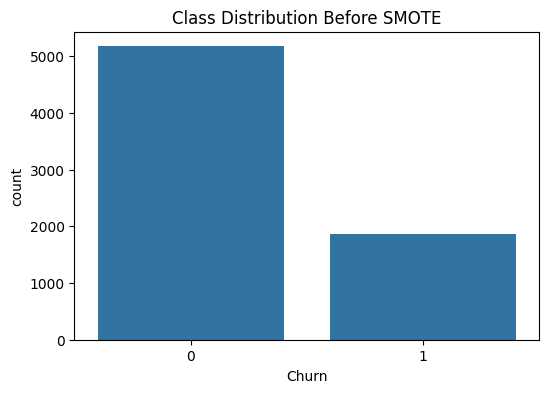

In [42]:
#Class Distribution Check
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Class Distribution Before SMOTE")
plt.show()

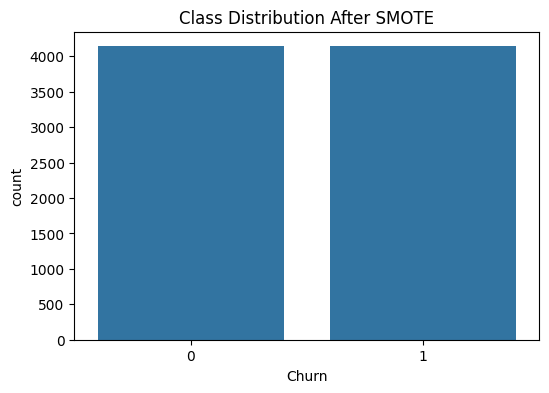

In [43]:
#SMOTE Visualization
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_smote)
plt.title("Class Distribution After SMOTE")
plt.show()

In [46]:
import joblib
joblib.dump(
    (X_train_smote, X_test, y_train_smote, y_test),
    "C:/Users/DAKSH/Downloads/customer-churn-prediction-advanced/models/processed_data.pkl"
)

['C:/Users/DAKSH/Downloads/customer-churn-prediction-advanced/models/processed_data.pkl']